# QC Review

Use this notebook after running `scripts/05_qc.py` to inspect per-sample QC plots and record filtering thresholds.

In [11]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path("..").resolve()
QC_DIR = REPO_ROOT / "results" / "qc"
PLOTS_DIR = REPO_ROOT / "plots" / "qc"

summary = pd.read_csv(QC_DIR / "qc_summary.tsv", sep="\t")
summary

,sample_id,n_cells,n_genes,median_total_counts,p05_total_counts,p95_total_counts,median_n_genes_by_counts,p05_n_genes_by_counts,p95_n_genes_by_counts,median_pct_counts_mt,pct_cells_mt_gt_20
0,GSM7494257_AML16_DX,6757,24343,7476.0,2091.80,23766.00,2214.0,831.80,4461.20,6.209705,0.0
1,GSM7494258_AML16_REL,4476,24343,7589.0,1981.50,20046.50,2104.5,824.00,3905.25,8.113030,0.0
2,GSM7494259_AML16_REM,5153,24343,7121.0,2864.80,12745.80,2208.0,1043.20,3117.40,5.829653,0.0
3,GSM7494260_AML6_DX,6327,23219,7827.0,2391.30,15154.70,2283.0,817.30,3416.70,8.141152,0.0
4,GSM7494261_AML6_REL,5358,23219,11184.5,3132.20,17195.05,2313.5,961.70,3295.30,5.728692,0.0
...,...,...,...,...,...,...,...,...,...,...,...
70,GSM7494327_AML12_REL,4686,23239,13728.5,2319.25,25106.00,2831.5,856.25,4147.75,4.146149,0.0
71,GSM7494328_AML12_REM,3278,23239,5965.5,2292.00,21792.70,1821.5,919.85,3722.35,3.935080,0.0
72,GSM7494329_AML13_DX,4410,23308,5876.5,2206.45,18616.85,1517.0,710.90,3176.65,6.828162,0.0
73,GSM7494330_AML13_REL,6838,23308,9927.5,1740.70,22596.65,2232.5,665.00,3643.00,6.993748,0.0


In [13]:
h5ad_files = sorted(QC_DIR.glob("*.h5ad"))
sample_ids = [path.stem for path in h5ad_files]

print(f"Found {len(sample_ids)} samples")
sample_ids[:10]

Found 75 samples


['GSM7494257_AML16_DX',
 'GSM7494258_AML16_REL',
 'GSM7494259_AML16_REM',
 'GSM7494260_AML6_DX',
 'GSM7494261_AML6_REL',
 'GSM7494262_AML6_REM',
 'GSM7494263_AML2_DX',
 'GSM7494264_AML2_REL',
 'GSM7494265_AML2_REM',
 'GSM7494266_AML15_DX']

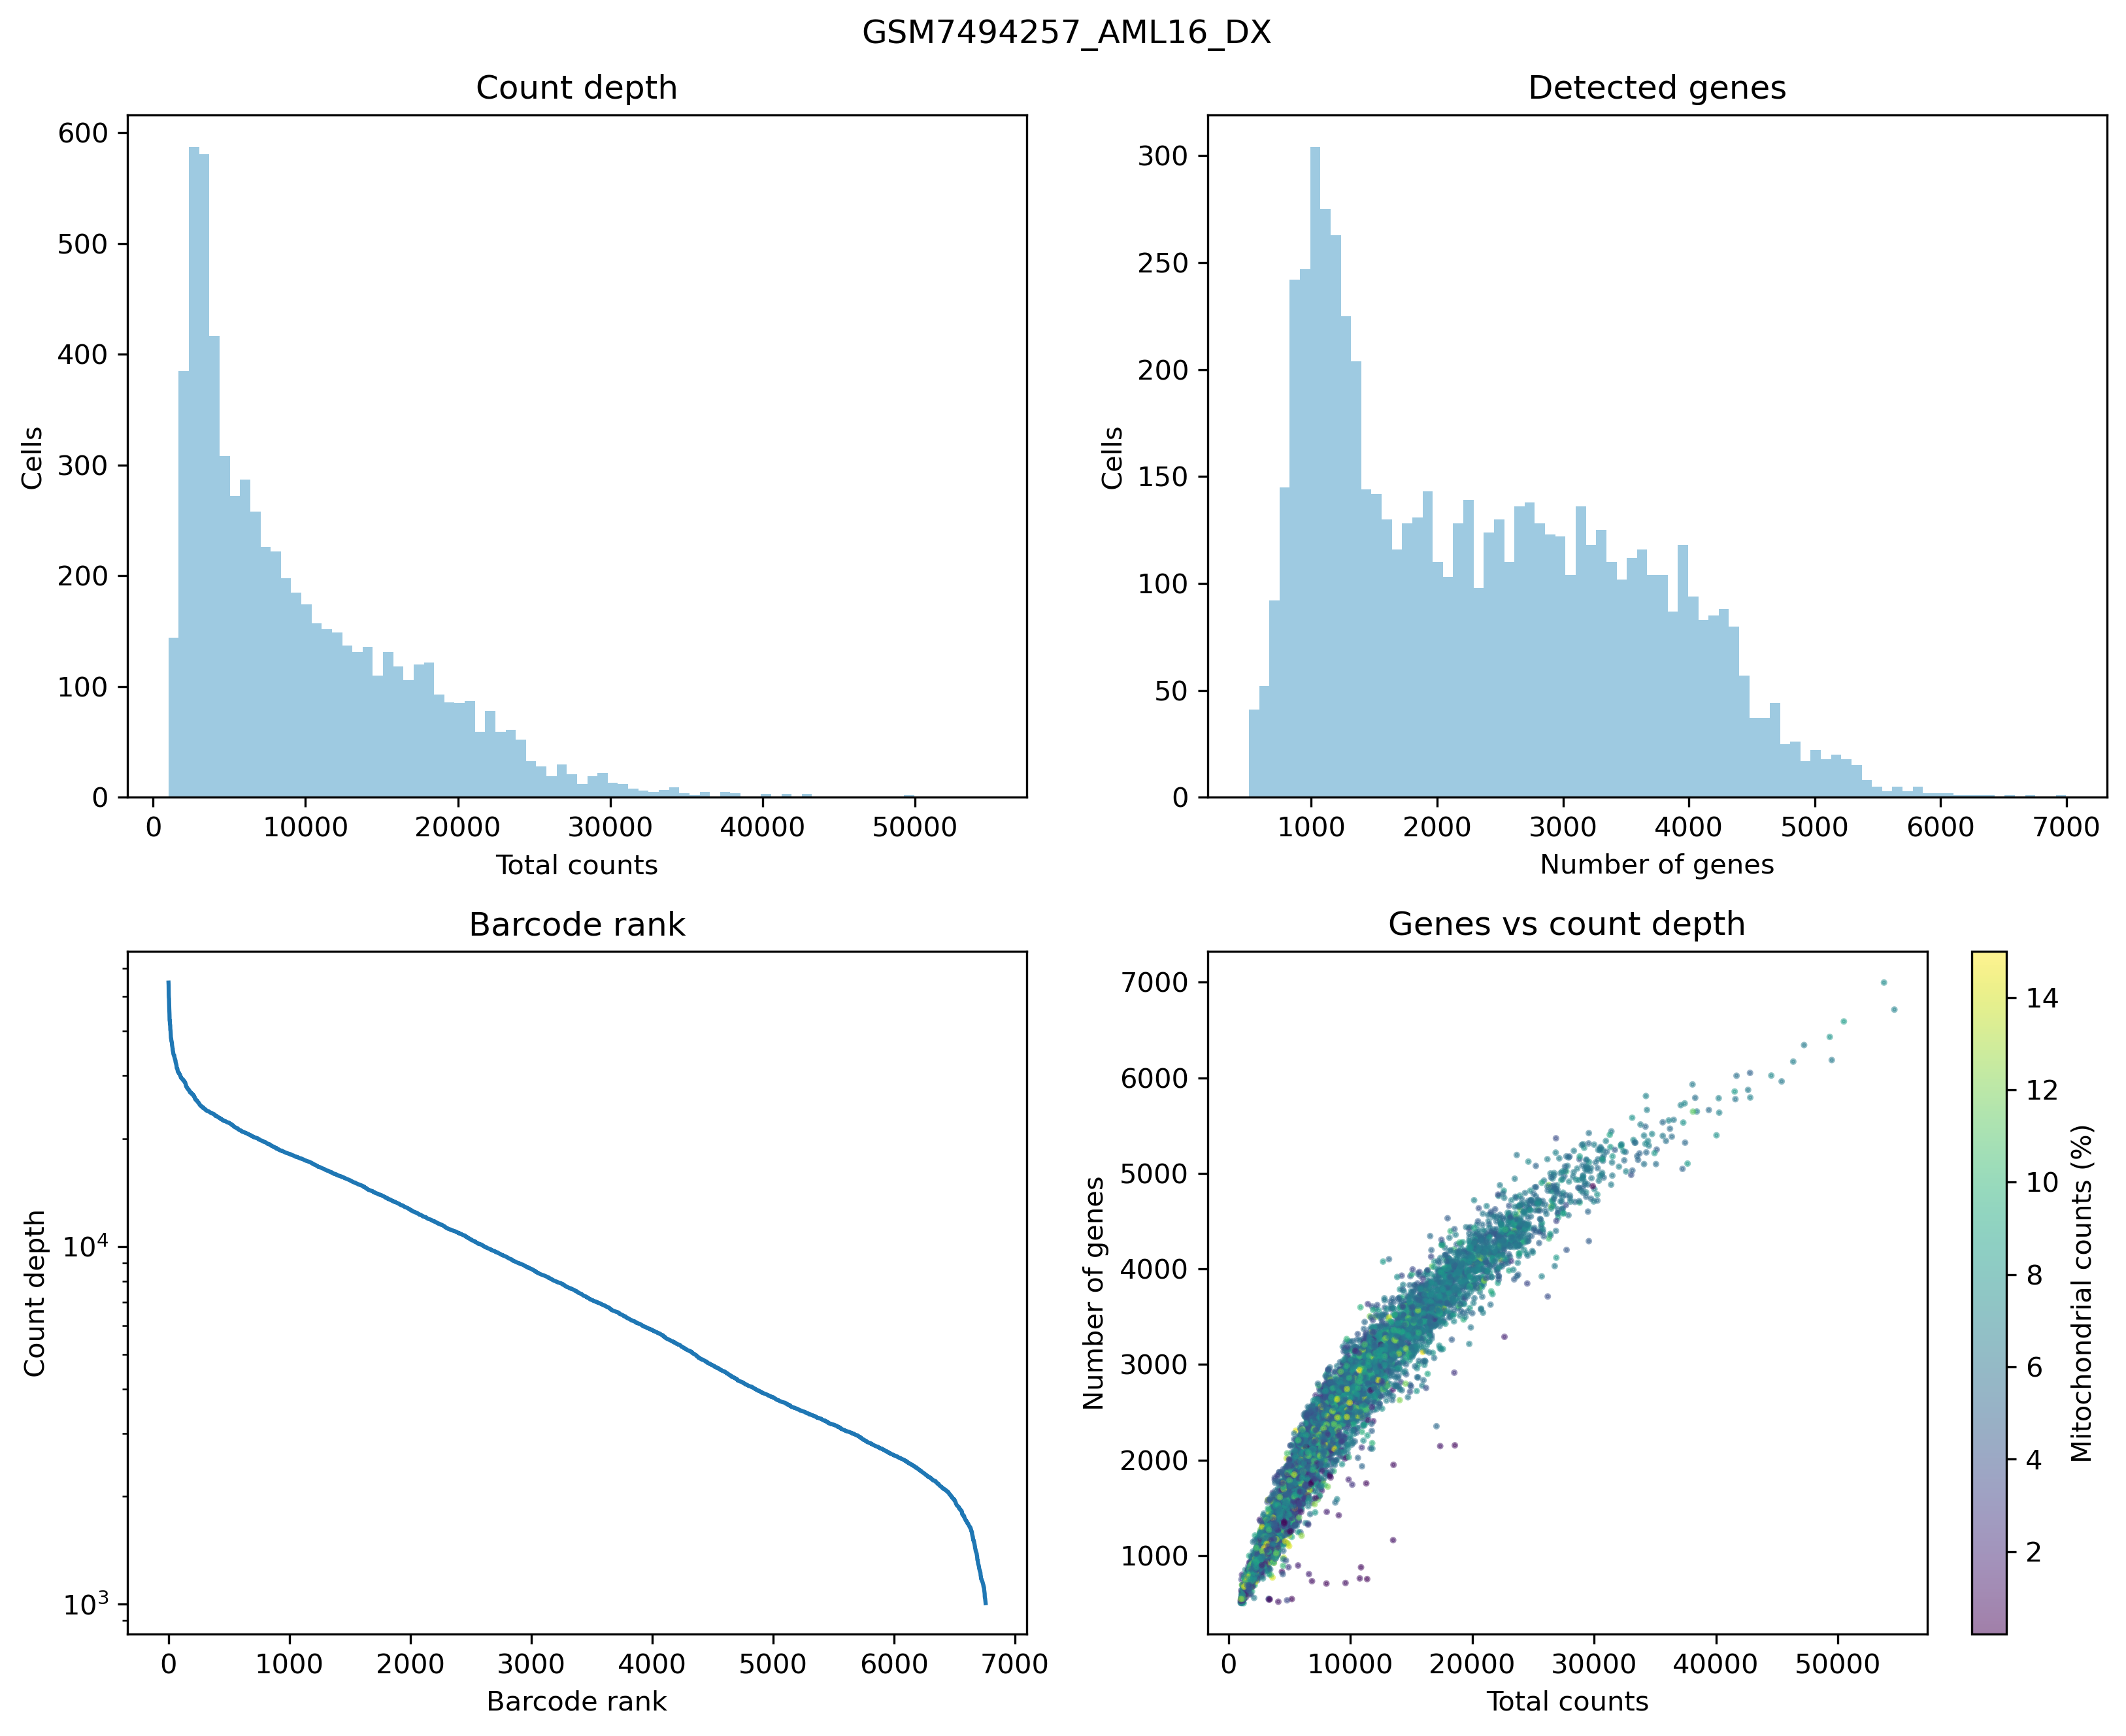

In [14]:
sample_id = sample_ids[0]
display(Image(filename=PLOTS_DIR / f"{sample_id}_qc.png"))

In [20]:
adata = ad.read_h5ad(QC_DIR / f"{sample_id}.h5ad")
obs = adata.obs

adata

AnnData object with n_obs × n_vars = 6757 × 24343
    obs: 'sample_id', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'mt'
    uns: 'source_h5'

In [21]:
min_counts = 1000
max_counts = 50000
min_genes = 500
max_genes = 6000
max_pct_mt = 20

qc_pass = (
    (obs["total_counts"] >= min_counts)
    & (obs["total_counts"] <= max_counts)
    & (obs["n_genes_by_counts"] >= min_genes)
    & (obs["n_genes_by_counts"] <= max_genes)
    & (obs["pct_counts_mt"] <= max_pct_mt)
)

pd.Series(
    {
        "sample_id": sample_id,
        "n_cells_before": adata.n_obs,
        "n_cells_after": int(qc_pass.sum()),
        "pct_cells_kept": round(float(qc_pass.mean() * 100), 2),
    }
)

sample_id         GSM7494257_AML16_DX
n_cells_before                   6757
n_cells_after                    6747
pct_cells_kept                  99.85
dtype: object

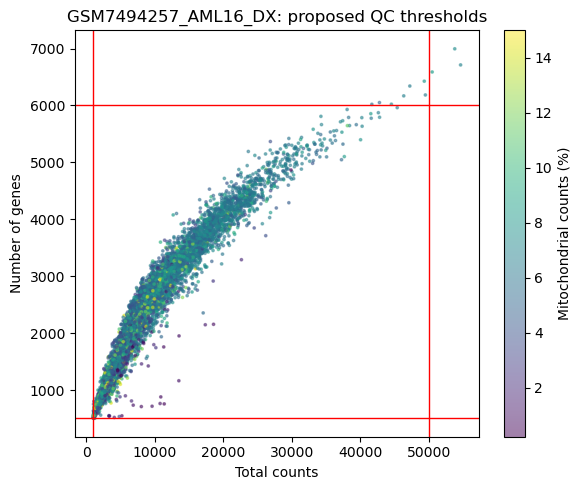

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(
    obs["total_counts"],
    obs["n_genes_by_counts"],
    c=obs["pct_counts_mt"],
    s=3,
    alpha=0.5,
    cmap="viridis",
)

ax.axvline(min_counts, color="red", linewidth=1)
ax.axvline(max_counts, color="red", linewidth=1)
ax.axhline(min_genes, color="red", linewidth=1)
ax.axhline(max_genes, color="red", linewidth=1)
ax.set_xlabel("Total counts")
ax.set_ylabel("Number of genes")
ax.set_title(f"{sample_id}: proposed QC thresholds")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Mitochondrial counts (%)")
fig.tight_layout()

In [17]:
qc_decision = pd.DataFrame(
    {
        "sample_id": [sample_id],
        "min_counts": [min_counts],
        "max_counts": [max_counts],
        "min_genes": [min_genes],
        "max_genes": [max_genes],
        "max_pct_mt": [max_pct_mt],
        "n_cells_before": [adata.n_obs],
        "n_cells_after": [int(qc_pass.sum())],
        "pct_cells_kept": [round(float(qc_pass.mean() * 100), 2)],
    }
)

qc_decision

,sample_id,min_counts,max_counts,min_genes,max_genes,max_pct_mt,n_cells_before,n_cells_after,pct_cells_kept
0,GSM7494257_AML16_DX,1000,50000,500,6000,20,6757,6747,99.85


In [19]:
thresholds_path = QC_DIR / "qc_thresholds.tsv"

if thresholds_path.exists():
    old_decisions = pd.read_csv(thresholds_path, sep="\t")
    old_decisions = old_decisions[old_decisions["sample_id"] != sample_id]
    qc_decisions = pd.concat([old_decisions, qc_decision], ignore_index=True)
else:
    qc_decisions = qc_decision

qc_decisions.to_csv(thresholds_path, sep="\t", index=False)
qc_decisions

,sample_id,min_counts,max_counts,min_genes,max_genes,max_pct_mt,n_cells_before,n_cells_after,pct_cells_kept
0,GSM7494257_AML16_DX,1000,50000,500,6000,20,6757,6747,99.85
